<a href="https://colab.research.google.com/github/RijulBhardwaj/Projects-At-Scaler/blob/main/Global_Development_Country_Segmentation_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Uncovering Hidden Country Segments for Global Development Strategy

End-to-end notebook implementing EDA, preprocessing, PCA, K-Means, Hierarchical Clustering, DBSCAN, evaluation and business insights.


In [1]:

# Install if needed
# !pip install yellowbrick kneed
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score,davies_bouldin_score,calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist


## Load Dataset

In [3]:

# Update path if required
from google.colab import files

uploaded = files.upload()

import pandas as pd
df = pd.read_csv('Country-data.csv')
display(df.head())
display(df.info())
display(df.describe(include='all'))
print(df.isna().sum())
print("Duplicates:",df.duplicated().sum())


Saving Country-data.csv to Country-data.csv


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
unique,167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,NaN,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,NaN,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,NaN,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,NaN,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,NaN,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000


country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64
Duplicates: 0


## EDA

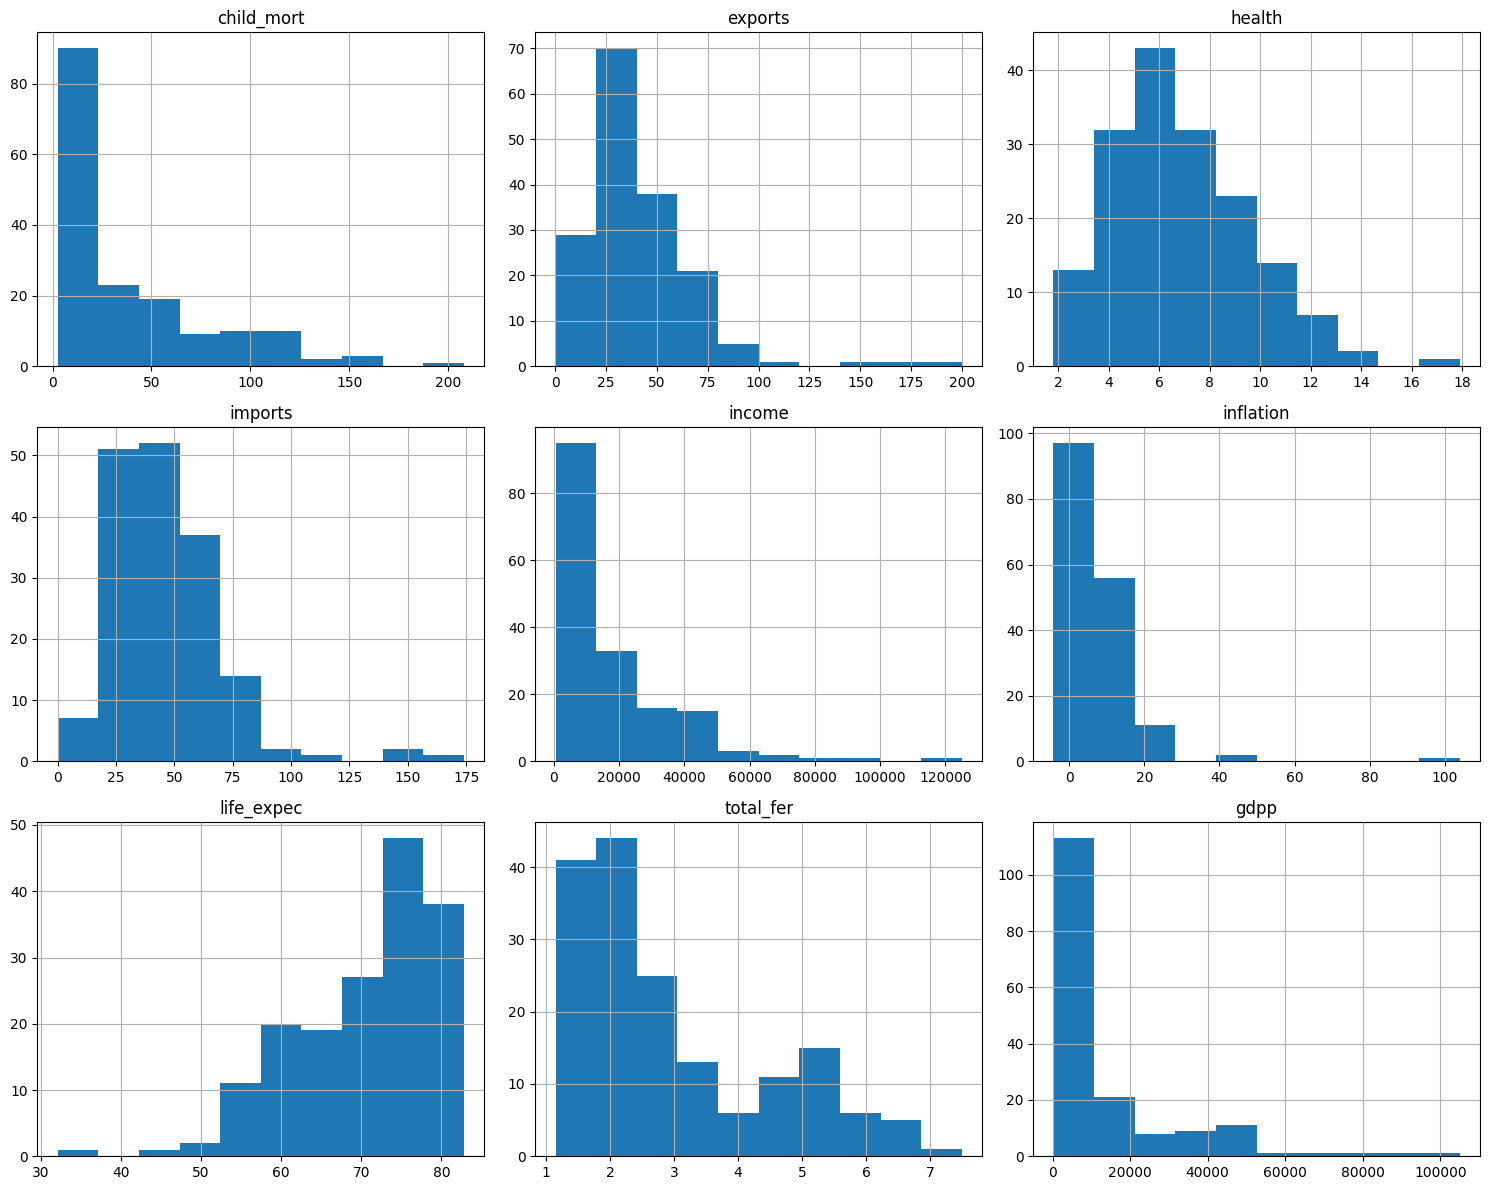

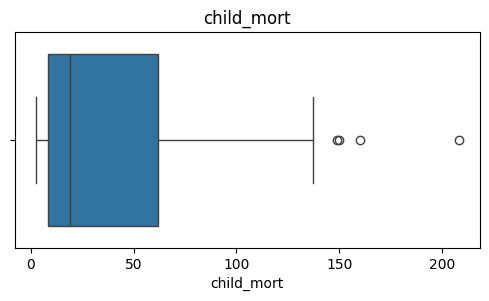

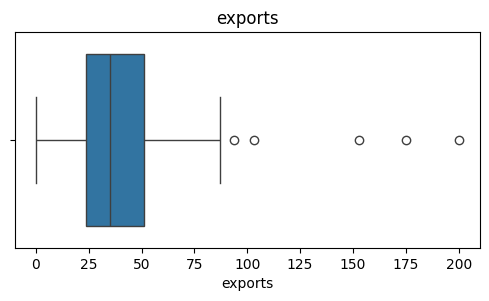

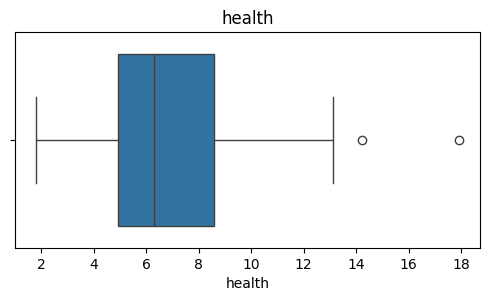

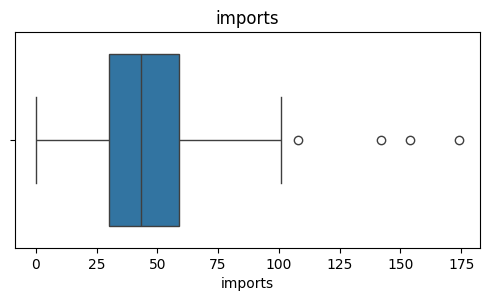

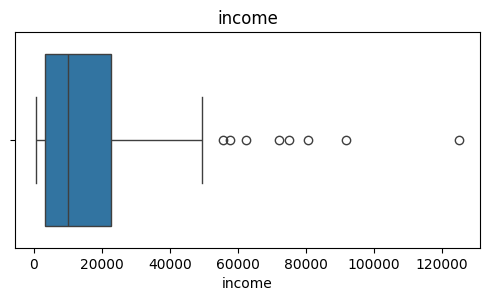

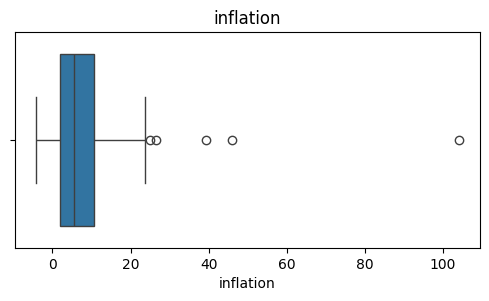

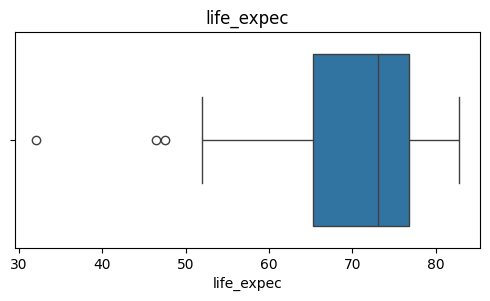

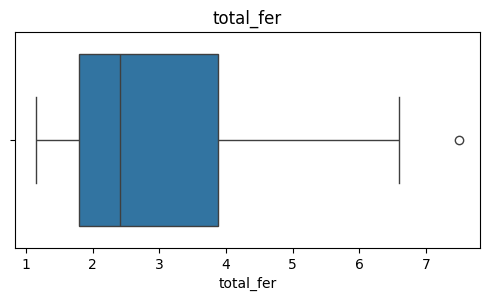

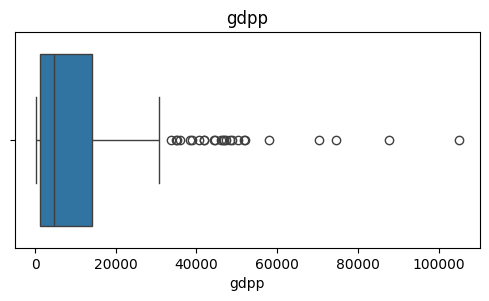

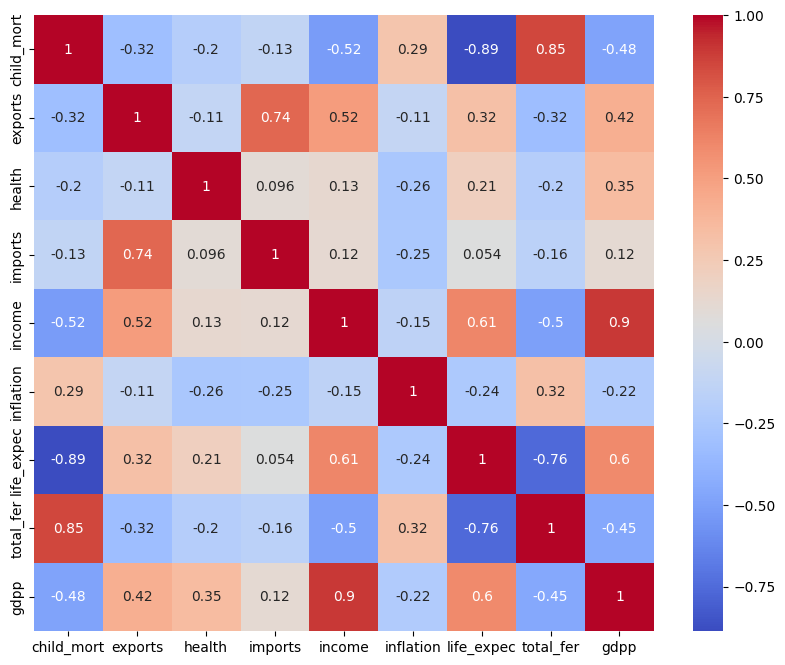

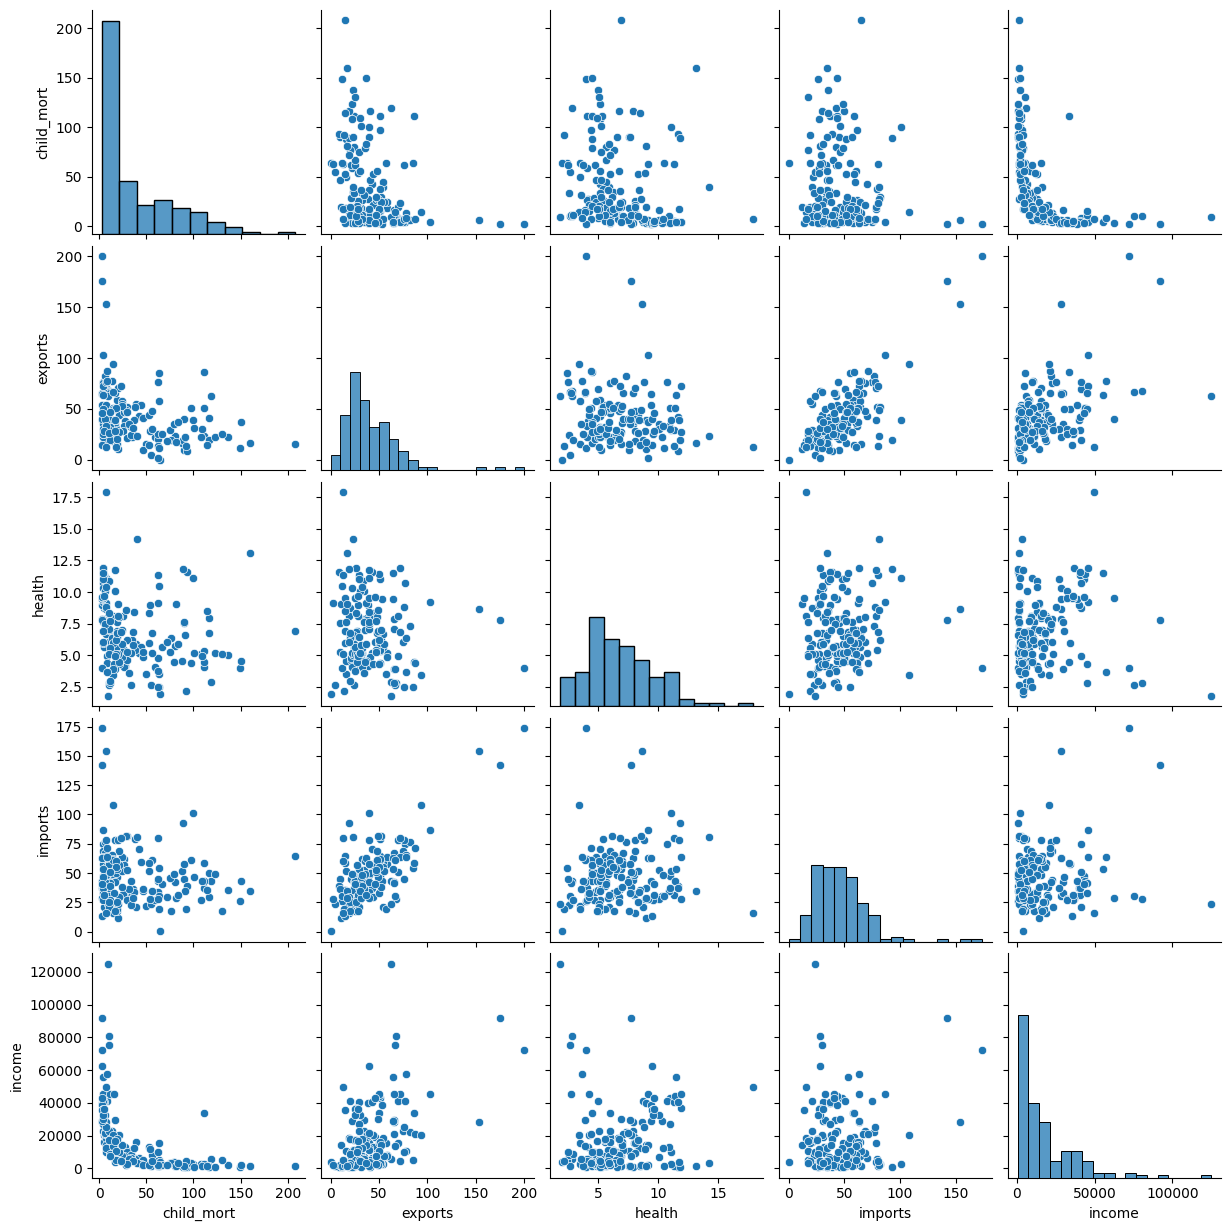

In [4]:

num=df.select_dtypes(include=np.number).columns

df[num].hist(figsize=(15,12))
plt.tight_layout()
plt.show()

for c in num:
    plt.figure(figsize=(6,2.8))
    sns.boxplot(x=df[c])
    plt.title(c)
    plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df[num].corr(),annot=True,cmap='coolwarm')
plt.show()

sns.pairplot(df[num[:5]])
plt.show()


## Top & Bottom Countries

In [5]:

for c in ['gdpp','income','life_expec','child_mort']:
    print("\n",c)
    display(df[['country',c]].nlargest(5,c))
    display(df[['country',c]].nsmallest(5,c))



 gdpp


,country,gdpp
91,Luxembourg,105000
114,Norway,87800
145,Switzerland,74600
123,Qatar,70300
44,Denmark,58000


,country,gdpp
26,Burundi,231
88,Liberia,327
37,"Congo, Dem. Rep.",334
112,Niger,348
132,Sierra Leone,399



 income


,country,income
123,Qatar,125000
91,Luxembourg,91700
23,Brunei,80600
82,Kuwait,75200
133,Singapore,72100


...

,country,life_expec
77,Japan,82.8
133,Singapore,82.7
145,Switzerland,82.2
7,Australia,82.0
68,Iceland,82.0


,country,life_expec
66,Haiti,32.1
87,Lesotho,46.5
31,Central African Republic,47.5
166,Zambia,52.0
94,Malawi,53.1



 child_mort


,country,child_mort
66,Haiti,208.0
132,Sierra Leone,160.0
32,Chad,150.0
31,Central African Republic,149.0
97,Mali,137.0


,country,child_mort
68,Iceland,2.6
91,Luxembourg,2.8
133,Singapore,2.8
53,Finland,3.0
144,Sweden,3.0


## Outlier Analysis (IQR)

In [6]:

out=df.copy()
for c in num:
    q1,q3=out[c].quantile([0.25,0.75])
    iqr=q3-q1
    lo=q1-1.5*iqr
    hi=q3+1.5*iqr
    print(c,((out[c]<lo)|(out[c]>hi)).sum(),"outliers")
# Do NOT cap if objective is identifying countries needing aid.


child_mort 4 outliers
exports 5 outliers
health 2 outliers
imports 4 outliers
income 8 outliers
inflation 5 outliers
life_expec 3 outliers
total_fer 1 outliers
gdpp 25 outliers


## Standard Scaling

In [7]:

X=df[num]
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)


## PCA

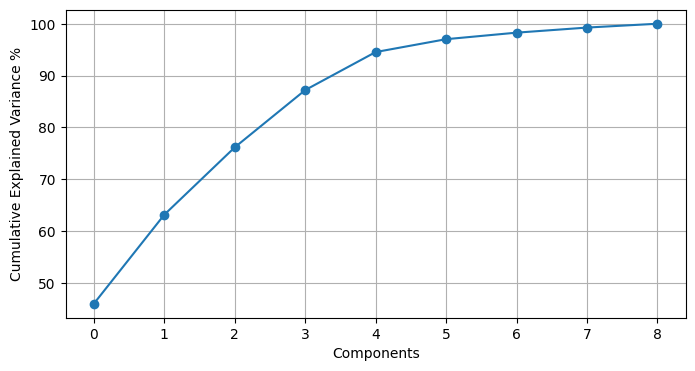

Components for >=90% variance: 5


,PC1,PC2,PC3,PC4,PC5
child_mort,-0.419519,0.192884,-0.029544,0.370653,-0.168970
exports,0.283897,0.613163,0.144761,0.003091,0.057616
health,0.150838,-0.243087,-0.596632,0.461897,0.518000
imports,0.161482,0.671821,-0.299927,-0.071907,0.255376
income,0.398441,0.022536,0.301548,0.392159,-0.247150
inflation,-0.193173,-0.008404,0.642520,0.150442,0.714869
life_expec,0.425839,-0.222707,0.113919,-0.203797,0.108220
total_fer,-0.403729,0.155233,0.019549,0.378304,-0.135262
gdpp,0.392645,-0.046022,0.122977,0.531995,-0.180167


In [8]:

pca=PCA()
X_pca=pca.fit_transform(X_scaled)

plt.figure(figsize=(8,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100,marker='o')
plt.xlabel("Components")
plt.ylabel("Cumulative Explained Variance %")
plt.grid()
plt.show()

n=np.argmax(np.cumsum(pca.explained_variance_ratio_)>=0.9)+1
print("Components for >=90% variance:",n)

pca=PCA(n_components=n)
X_red=pca.fit_transform(X_scaled)

loadings=pd.DataFrame(pca.components_.T,index=num,
columns=[f"PC{i+1}" for i in range(n)])
display(loadings)


## Elbow & Silhouette

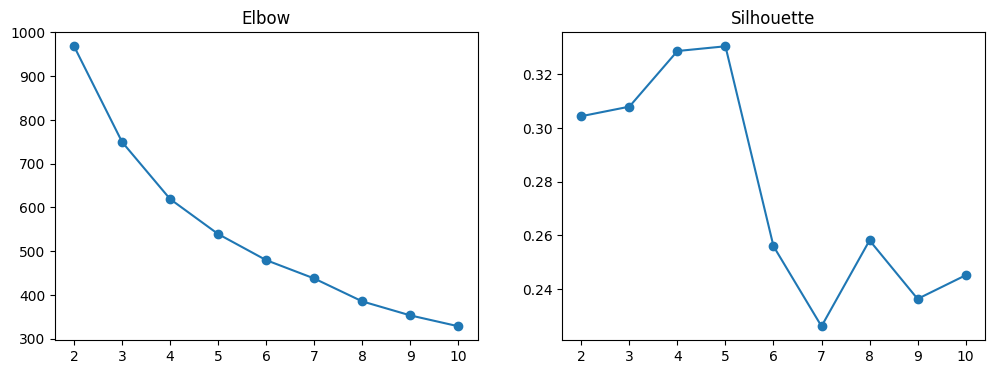

5


In [9]:

sse=[]
sil=[]
ks=range(2,11)
for k in ks:
    km=KMeans(n_clusters=k,random_state=42,n_init=10)
    lab=km.fit_predict(X_red)
    sse.append(km.inertia_)
    sil.append(silhouette_score(X_red,lab))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(list(ks),sse,marker='o')
plt.title("Elbow")

plt.subplot(1,2,2)
plt.plot(list(ks),sil,marker='o')
plt.title("Silhouette")
plt.show()

best_k=list(ks)[np.argmax(sil)]
print(best_k)


## KMeans

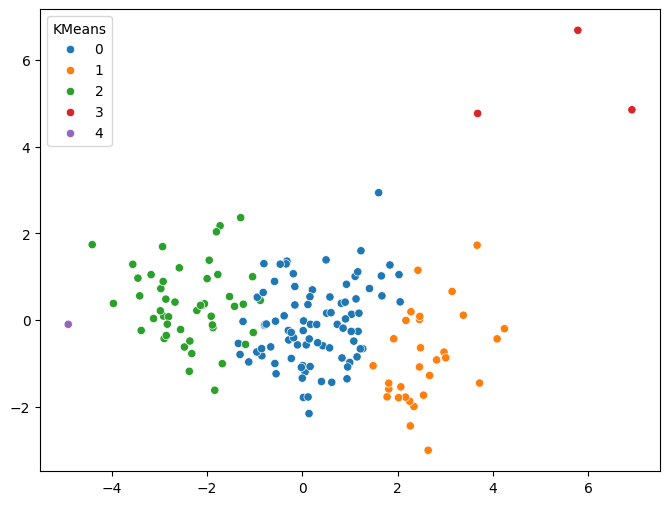

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans,,,,,,,,,
0,20.889535,41.769535,6.285465,48.596512,13076.162791,7.417802,73.006977,2.285116,6988.069767
1,4.953333,45.826667,9.168667,39.736667,45250.000000,2.742200,80.376667,1.795333,43333.333333
2,91.565957,28.615298,6.322553,41.954594,3911.978723,9.956702,59.321277,4.935106,1893.829787
3,4.133333,176.000000,6.793333,156.666667,64033.333333,2.468000,81.433333,1.380000,57566.666667
4,130.000000,25.300000,5.070000,17.400000,5150.000000,104.000000,60.500000,5.840000,2330.000000


,Cluster,Representative Country
0,0,Suriname
1,1,Finland
2,2,Gambia
3,3,Singapore
4,4,Nigeria


In [10]:

kmeans=KMeans(n_clusters=best_k,random_state=42,n_init=10)
df['KMeans']=kmeans.fit_predict(X_red)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_red[:,0],y=X_red[:,1],hue=df['KMeans'],palette='tab10')
plt.show()

profile=df.groupby('KMeans')[num].mean()
display(profile)

centers=kmeans.cluster_centers_
dist=cdist(X_red,centers)
rep=np.argmin(dist,axis=0)

representatives=pd.DataFrame({
'Cluster':range(best_k),
'Representative Country':df.iloc[rep]['country'].values
})
display(representatives)


## Hierarchical Clustering

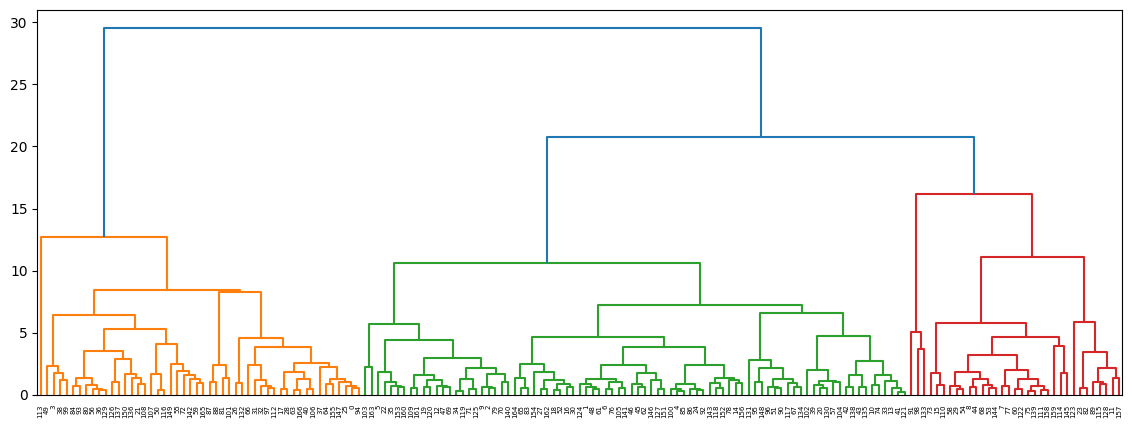

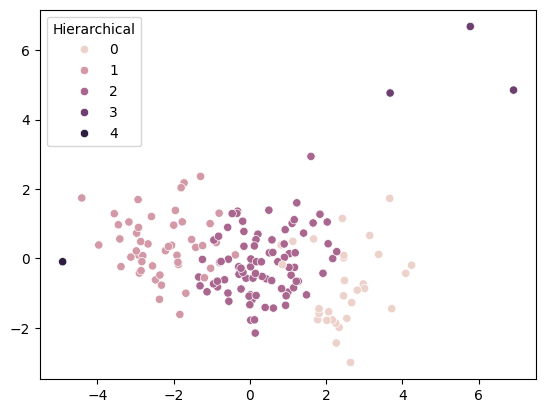

In [11]:

Z=linkage(X_red,method='ward')
plt.figure(figsize=(14,5))
dendrogram(Z)
plt.show()

agg=AgglomerativeClustering(n_clusters=best_k)
df['Hierarchical']=agg.fit_predict(X_red)

sns.scatterplot(x=X_red[:,0],y=X_red[:,1],hue=df['Hierarchical'])
plt.show()


## DBSCAN

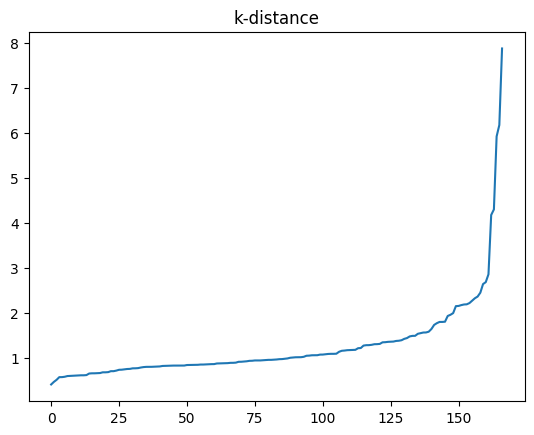

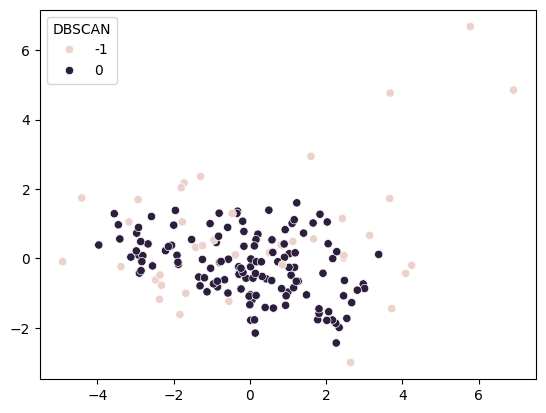

['Angola', 'Bahrain', 'Belgium', 'Brunei', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Haiti', 'Ireland', 'Kiribati', 'Kuwait', 'Lesotho', 'Liberia', 'Libya', 'Luxembourg', 'Malta', 'Micronesia, Fed. Sts.', 'Moldova', 'Mongolia', 'Myanmar', 'Nigeria', 'Norway', 'Oman', 'Pakistan', 'Qatar', 'Rwanda', 'Saudi Arabia', 'Seychelles', 'Sierra Leone', 'Singapore', 'Sudan', 'Switzerland', 'Timor-Leste', 'Turkmenistan', 'United Arab Emirates', 'United States', 'Venezuela']


In [12]:

nbrs=NearestNeighbors(n_neighbors=5).fit(X_red)
dists,_=nbrs.kneighbors(X_red)
d=np.sort(dists[:,4])

plt.plot(d)
plt.title("k-distance")
plt.show()

db=DBSCAN(eps=1.2,min_samples=5)
df['DBSCAN']=db.fit_predict(X_red)

sns.scatterplot(x=X_red[:,0],y=X_red[:,1],hue=df['DBSCAN'])
plt.show()

print(df[df.DBSCAN==-1]['country'].tolist())


## Model Evaluation

In [13]:

def metrics(X,l):
    if len(set(l))<2:
        return None
    return [
        silhouette_score(X,l),
        davies_bouldin_score(X,l),
        calinski_harabasz_score(X,l)
    ]

results=pd.DataFrame({
'Model':['KMeans','Hierarchical'],
'Silhouette':[metrics(X_red,df.KMeans)[0],metrics(X_red,df.Hierarchical)[0]],
'DaviesBouldin':[metrics(X_red,df.KMeans)[1],metrics(X_red,df.Hierarchical)[1]],
'CalinskiHarabasz':[metrics(X_red,df.KMeans)[2],metrics(X_red,df.Hierarchical)[2]]
})
display(results)


,Model,Silhouette,DaviesBouldin,CalinskiHarabasz
0,KMeans,0.330454,0.805527,66.198771
1,Hierarchical,0.318641,0.855603,62.763843


## Business Questions

  1. Without scaling, high-magnitude variables like **gdpp** and **income** dominate Euclidean distance while life expectancy and fertility contribute very little.

2. Capping extreme child mortality removes exactly the countries requiring urgent intervention, reducing the ability to identify high-need segments.

3. A high silhouette score indicates clusters are compact internally and well separated from each other.

4. A dendrogram reveals hierarchical relationships, merge distances, and natural nested groupings that a K-Means scatter plot cannot.

5. High-income/high-health clusters should focus on innovation, sustainability and knowledge sharing. Low-income/low-health clusters require aid, healthcare investment, education and infrastructure.

6. Representative countries provide an intuitive real-world example for communicating the characteristics of each cluster to policymakers.

7. High trade but low GDP suggests improving value addition, industrialization, logistics, export diversification and domestic manufacturing instead of merely increasing trade volume.


## Executive Summary

- Performed EDA and preprocessing.
- Standardized variables.
- Reduced dimensionality using PCA.
- Compared K-Means, Hierarchical Clustering and DBSCAN.
- Evaluated using Silhouette, Davies-Bouldin and Calinski-Harabasz indices.
- Profiled country clusters and identified representative countries.
- Proposed targeted development policies for each segment.


1. If Standard Scaling was skipped, which features (e.g., gdpp vs. life_expec) would unfairly dominate the clustering distance calculation?

Answer:

Without Standard Scaling, features with much larger numerical ranges, such as GDP per capita (gdpp) and income, would dominate the Euclidean distance calculations used by clustering algorithms like K-Means. Features with smaller ranges, such as life expectancy (life_expec), health expenditure (health), and total fertility (total_fer), would contribute very little to cluster formation. As a result, countries would be grouped mainly based on economic indicators rather than considering all socio-economic characteristics equally. Standard Scaling ensures that every feature contributes equally to the clustering process.

2. Why might capping extreme high/low values (like max child_mort) be counterproductive when the goal is to identify countries in the most critical need of aid?

Answer:

Extreme values often represent countries facing severe socio-economic challenges. For example, a very high child mortality (child_mort) rate indicates countries that require urgent healthcare and development support. Capping these values would reduce the distinction between the most vulnerable countries and others, making them appear less critical than they actually are. Since the objective is to identify countries most in need of aid, preserving genuine outliers allows the clustering algorithm to accurately identify high-priority countries.

3. If K-Means yields a very high Silhouette Score, what does this imply about the separation and cohesion of the identified country segments?

Answer:

A very high Silhouette Score indicates that:

Countries within the same cluster are highly similar (high cohesion).
Different clusters are well separated from one another (high separation).
There is minimal overlap between clusters.
The clustering solution is reliable and meaningful for decision-making.

This suggests that the identified country segments are distinct and suitable for designing targeted development policies.

4. What unique policy insight does a Hierarchical Clustering Dendrogram offer that a K-Means scatter plot does not, regarding the relationships between clusters?

Answer:

A Hierarchical Clustering Dendrogram shows how clusters are related by illustrating the order and distance at which they merge. Unlike a K-Means scatter plot, which only displays the final cluster assignments, a dendrogram helps policymakers:

Understand the similarity between different country groups.
Identify natural sub-groups within larger clusters.
Choose the most appropriate number of clusters.
Explore multiple levels of segmentation for policy planning.

This provides greater flexibility in designing development strategies.

5. Segment A has high income and high health spend. Segment B has low income and low health spend. What distinct policy goal should be set for Segment A vs. Segment B?

Answer:

Segment A (High Income & High Health Spend)

Promote sustainable economic growth.
Invest in healthcare innovation and advanced medical research.
Improve healthcare efficiency.
Share knowledge and best practices with developing countries.

Segment B (Low Income & Low Health Spend)

Improve access to basic healthcare services.
Reduce poverty and child mortality.
Increase investment in education, sanitation, and public health.
Develop essential infrastructure.
Provide targeted international development assistance.

6. What is the business purpose of identifying the country closest to a cluster's centroid (the "representative country") for policy communication?

Answer:

The representative country is the country whose characteristics are closest to the cluster centroid, making it the best example of that cluster. It helps policymakers and stakeholders:

Understand the overall characteristics of the cluster.
Communicate findings using a real-world example.
Validate and interpret cluster profiles.
Develop cluster-specific policies based on a representative country.

7. A cluster profile shows high average exports and imports but low gdpp. What is the immediate, tailored policy recommendation for this "Mid-Income Traders" segment?

Answer:

Although these countries actively participate in international trade, they are not generating proportional economic growth. The recommended policy actions are:

Increase domestic value addition through manufacturing.
Promote industrialization and technology adoption.
Diversify exports toward higher-value products.
Improve logistics and supply chain infrastructure.
Encourage innovation and productivity in domestic industries.

These initiatives will help convert strong trade performance into sustainable GDP growth and long-term economic development.